In [9]:
import numpy as np
import cv2
import pickle
import struct
import bz2
import os
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

with open('phase4_results.pkl', 'rb') as f:
    p4 = pickle.load(f)

img = p4['img']  # only used to compute SSIM/PSNR against, not used during decoding
compressed = p4['compressed_data']

chain_data = bz2.decompress(compressed)
print(f"Decompressed size: {len(chain_data)} bytes")

Decompressed size: 546580 bytes


In [10]:
offset = 0

height, width = struct.unpack_from('>HH', chain_data, offset)
offset += 4

palette_size = struct.unpack_from('>H', chain_data, offset)[0]
offset += 2

palette = []
for _ in range(palette_size):
    r, g, b = struct.unpack_from('BBB', chain_data, offset)
    offset += 3
    palette.append((r, g, b))

total_regions = struct.unpack_from('>I', chain_data, offset)[0]
offset += 4

print(f"Image size: {height}x{width}")
print(f"Palette size: {palette_size}")
print(f"Total regions to decode: {total_regions}")

Image size: 393x800
Palette size: 982
Total regions to decode: 13658


In [11]:
def read_runs_header(chain_data, offset):
    """Read run count and (row, start_col, length) for each run."""
    num_runs = struct.unpack_from('>I', chain_data, offset)[0]
    offset += 4
    runs = []
    for _ in range(num_runs):
        row, start_col, length = struct.unpack_from('>HHH', chain_data, offset)
        offset += 6
        runs.append((row, start_col, length))
    return runs, offset

recon = np.zeros((height, width, 3), dtype=np.uint8)
filled_pixels = 0

for i in range(total_regions):
    region_type = struct.unpack_from('B', chain_data, offset)[0]
    offset += 1

    if region_type == 2:  # special: exact per-pixel RGB, exact pixel runs
        runs, offset = read_runs_header(chain_data, offset)
        for row, start_col, length in runs:
            for x in range(start_col, start_col + length):
                r, g, b = struct.unpack_from('BBB', chain_data, offset)
                offset += 3
                recon[row, x] = (r, g, b)
            filled_pixels += length

    elif region_type == 1:  # gradient: direction + start/end colors, exact pixel runs
        direction = struct.unpack_from('B', chain_data, offset)[0]
        offset += 1
        start_color = np.array(struct.unpack_from('BBB', chain_data, offset), dtype=float)
        offset += 3
        end_color = np.array(struct.unpack_from('BBB', chain_data, offset), dtype=float)
        offset += 3
        runs, offset = read_runs_header(chain_data, offset)

        pixels = []
        for row, start_col, length in runs:
            for x in range(start_col, start_col + length):
                pixels.append((row, x))

        if pixels:
            pixels_arr = np.array(pixels)
            angle_rad = np.radians(direction * 45)
            dir_vec = np.array([np.cos(angle_rad), np.sin(angle_rad)])
            projections = pixels_arr @ dir_vec
            proj_min, proj_max = projections.min(), projections.max()
            if proj_max > proj_min:
                norm = (projections - proj_min) / (proj_max - proj_min)
            else:
                norm = np.ones(len(projections)) * 0.5

            for j, (y, x) in enumerate(pixels_arr):
                t = norm[j]
                recon[y, x] = np.clip((1 - t) * start_color + t * end_color, 0, 255).astype(np.uint8)
            filled_pixels += len(pixels)

    else:  # region_type == 0, flat: palette color, exact pixel runs
        pal_idx = struct.unpack_from('>H', chain_data, offset)[0]
        offset += 2
        runs, offset = read_runs_header(chain_data, offset)

        color = np.array(palette[pal_idx], dtype=np.uint8)
        for row, start_col, length in runs:
            recon[row, start_col:start_col + length] = color
            filled_pixels += length

coverage = filled_pixels / (height * width) * 100
print(f"Decoded {total_regions} regions")
print(f"Filled pixels: {filled_pixels} / {height*width} ({coverage:.2f}%)")

Decoded 13658 regions
Filled pixels: 314400 / 314400 (100.00%)


SSIM: 0.9291
PSNR: 22.60 dB


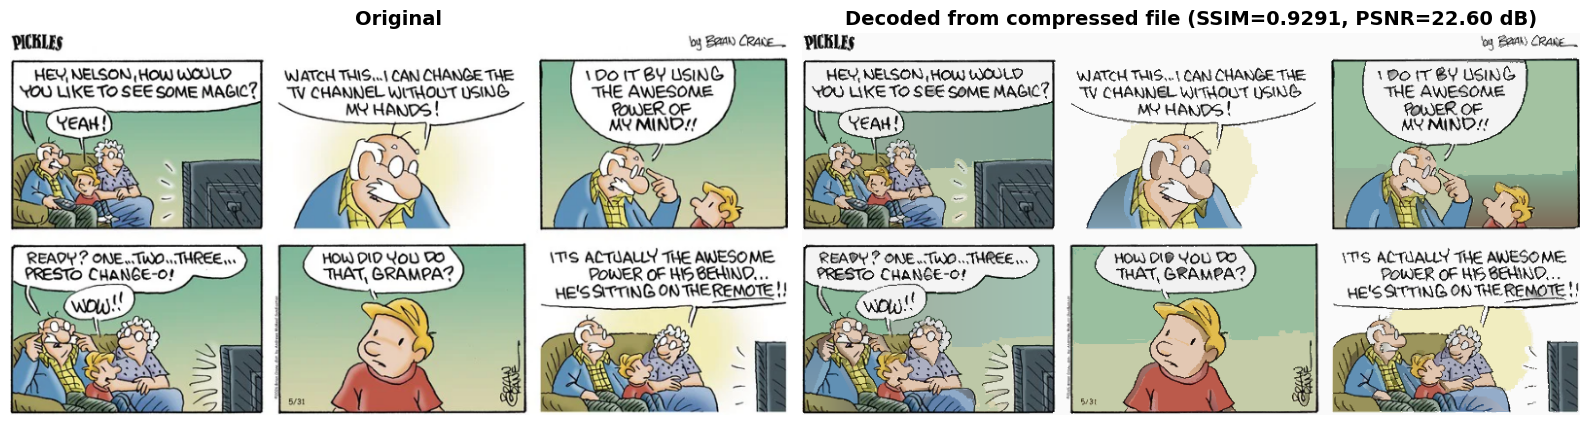

In [12]:
recon_path = os.path.join("comic", "phase5_reconstruction.jpg")
os.makedirs("comic", exist_ok=True)
cv2.imwrite(recon_path, cv2.cvtColor(recon, cv2.COLOR_RGB2BGR))

ssim = ssim_fn(img, recon, channel_axis=2)
psnr = psnr_fn(img, recon)
print(f"SSIM: {ssim:.4f}")
print(f"PSNR: {psnr:.2f} dB")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(np.uint8(img))
axes[0].set_title('Original', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(np.uint8(recon))
axes[1].set_title(f'Decoded from compressed file (SSIM={ssim:.4f}, PSNR={psnr:.2f} dB)',
                  fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join("comic", "phase5_comparison.jpg"), dpi=150, bbox_inches='tight')
plt.show()